# Argo Stirring & Mixing Dashboard

Goal here is to make a notebook that has interactive plots of the following:
- large-scale tracer field
- tracer gradients
- mesoscale and microscale variance, and the associated fractions
- eddy diffusivity
- eddy fluxes

I'm both hopefull and optimistic that the updates to gyre will allow me to do this here, but if not, I'll have to either run this notebook locally or on the LEAP hub. 

In [17]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
from matplotlib.widgets import Slider
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cmocean.cm as cmo
import cartopy.crs as ccrs
import gsw

In [18]:
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']  = 18
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

In [19]:
ds_pbar = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_var.nc')
ds_pbar_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_var.nc')
ds_pbar_grad = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grad_cip_masking.nc')
ds_pbar_grid = ds_pbar_grid.assign_coords(LON_left = ds_pbar_grad.LON_left,LAT_left = ds_pbar_grad.LAT_left)
ds_pbar_grid = xr.merge([ds_pbar_grid, ds_pbar_grad.drop_vars({'DENSITY'})])

In [20]:
K_rho_p = xr.open_dataarray('/swot/SUM05/amf2288/K_rho_filt_p.nc').drop_vars('Z').rename({'PRESSURE':'PRESSURE_mean'})
K_rho_p = K_rho_p.bfill(dim='PRESSURE_mean').ffill(dim='PRESSURE_mean')

## Diapycnal Diffusivity

interactive(children=(FloatSlider(value=1000.0, continuous_update=False, description='Depth (m)', max=2000.0, …

<function __main__.plot_depth(depth)>

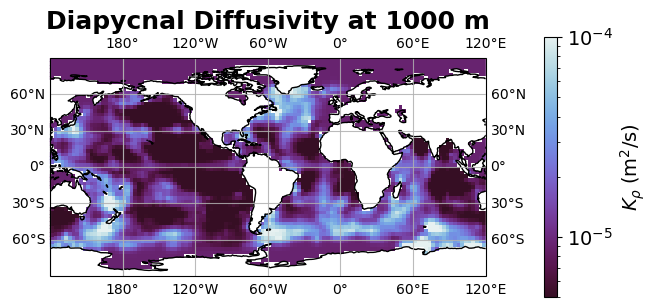

In [25]:
%matplotlib inline

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean.cm as cmo
from matplotlib import colors
import ipywidgets as widgets
from ipywidgets import interact

# Depth range from your dataset
depth_min = float(K_rho_p.PRESSURE_mean.min())
depth_max = float(K_rho_p.PRESSURE_mean.max())
depth0    = 1000.0

# Create figure + axis once
fig = plt.figure(figsize=(7.5, 3.75))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=-60))

# Keep a reference to the colorbar so we can update it
cbar = None

def plot_depth(depth):
    global cbar

    ax.clear()

    da = K_rho_p.sel(PRESSURE_mean=depth, method='nearest')

    pcm = da.plot(
        x='LON', y='LAT',
        cmap=cmo.dense_r,
        norm=colors.LogNorm(5e-6, 1e-4),
        transform=ccrs.PlateCarree(),
        add_colorbar=False,
        ax=ax
    )

    if cbar is None:
        cbar = fig.colorbar(
            pcm, ax=ax,
            shrink=0.9, pad=0.1,
            label=r'$K_\rho \; (\mathrm{m}^2/\mathrm{s})$'
        )
    else:
        cbar.update_normal(pcm)

    ax.coastlines()
    ax.gridlines(draw_labels=True, alpha=0.85)
    ax.set_title(f"Diapycnal Diffusivity at {float(da.PRESSURE_mean.values):.0f} m")

    fig.canvas.draw_idle()

depth_slider = widgets.FloatSlider(
    value=depth0,
    min=depth_min,
    max=depth_max,
    step=50,
    description='Depth (m)',
    continuous_update=False
)

interact(plot_depth, depth=depth_slider)